In [1]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [3]:
df_train = df_train[df_train['emotion'].isin(['angry', 'happy', 'sad'])]
df_val   = df_val[df_val['emotion'].isin(['angry', 'happy', 'sad'])]
df_test  = df_test[df_test['emotion'].isin(['angry', 'happy', 'sad'])]

In [4]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    max_len = 3 * sr
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    return mfcc.T   # (T, 40)

In [5]:
def process_dataframe(df):
    X, y = [], []

    for _, row in df.iterrows():
        try:
            features = extract_features(row['path'])
            X.append(features)
            y.append(row['emotion'])
        except:
            continue

    return np.array(X), np.array(y)

In [6]:
X_train, y_train = process_dataframe(df_train)
X_val, y_val     = process_dataframe(df_val)
X_test, y_test   = process_dataframe(df_test)

print("Train:", X_train.shape)

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: (3084, 130, 40)


In [7]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

In [8]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)
y_test_cat  = to_categorical(y_test_enc)

In [9]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 130, 128)          86528     
                                                                 
 dropout (Dropout)           (None, 130, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 3)                 1

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/30
97/97 [==============================] - 54s 469ms/step - loss: 0.9749 - accuracy: 0.4912 - val_loss: 1.0047 - val_accuracy: 0.4750 - lr: 0.0010
Epoch 2/30
97/97 [==============================] - 35s 359ms/step - loss: 0.9041 - accuracy: 0.5396 - val_loss: 1.0055 - val_accuracy: 0.4960 - lr: 0.0010
Epoch 3/30
97/97 [==============================] - 46s 471ms/step - loss: 0.8680 - accuracy: 0.5642 - val_loss: 0.9541 - val_accuracy: 0.5201 - lr: 0.0010
Epoch 4/30
97/97 [==============================] - 43s 446ms/step - loss: 0.8330 - accuracy: 0.5970 - val_loss: 0.9094 - val_accuracy: 0.5717 - lr: 0.0010
Epoch 5/30
97/97 [==============================] - 37s 377ms/step - loss: 0.8028 - accuracy: 0.6128 - val_loss: 0.9661 - val_accuracy: 0.5700 - lr: 0.0010
Epoch 6/30
97/97 [==============================] - 30s 312ms/step - loss: 0.8677 - accuracy: 0.5730 - val_loss: 0.9635 - val_accuracy: 0.5298 - lr: 0.0010
Epoch 7/30
97/97 [==============================] - 31s 318ms/st

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("LSTM Accuracy:", test_acc)

22/22 [==============================] - 1s 36ms/step - loss: 0.5342 - accuracy: 0.7909
LSTM Accuracy: 0.7909356951713562


In [19]:
print(" Training Accuracy:", history.history['accuracy'][-1])

 Training Accuracy: 0.744163453578949


In [20]:
print(" Validation Accuracy:", max(history.history['val_accuracy']))

 Validation Accuracy: 0.6763284802436829


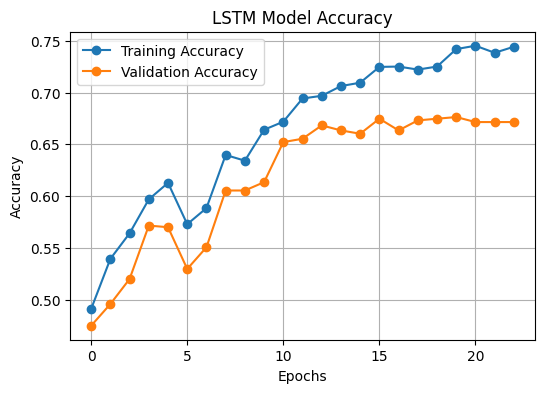

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.savefig('lstm_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

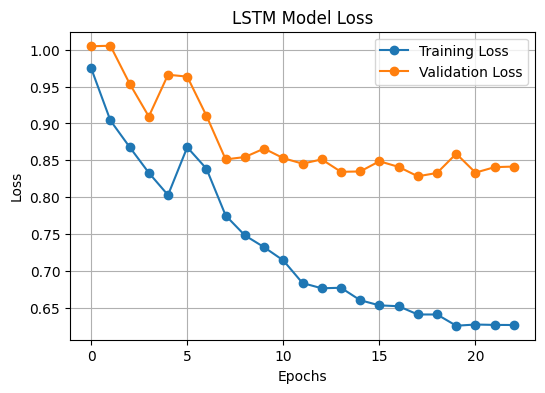

In [15]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)

plt.savefig('lstm_loss.png', dpi=300, bbox_inches='tight')
plt.show()

22/22 [==============================] - 1s 32ms/step


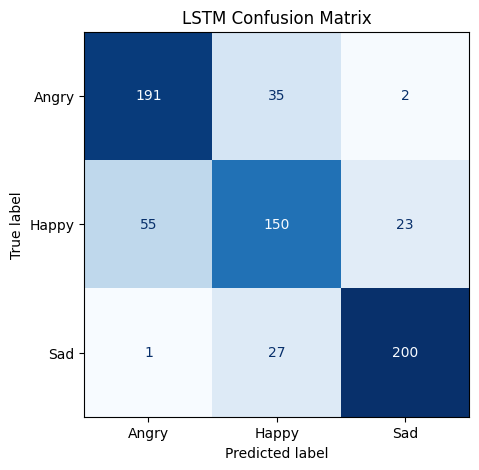

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

labels = ['Angry', 'Happy', 'Sad']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('LSTM Confusion Matrix')
plt.savefig('lstm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=['Angry', 'Happy', 'Sad']
)

print(report)

              precision    recall  f1-score   support

       Angry       0.77      0.84      0.80       228
       Happy       0.71      0.66      0.68       228
         Sad       0.89      0.88      0.88       228

    accuracy                           0.79       684
   macro avg       0.79      0.79      0.79       684
weighted avg       0.79      0.79      0.79       684



In [18]:
model.save("lstm_model.h5")   

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
